In [1]:
import numpy as np
import pandas as pd
import PF_func_emperical as func_PF
import IP_PFSMG_OG as pfsmg                # Original Python-code from Liu and Vicente 
import IP_functions_OG as func_IP          # Original Python-code from Liu and Vicente
import train_classifiers as train
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import pickle
import time 
import seaborn as sns

In [2]:
# Define parameters
dataset = 'Adult_income_gender_reduced'
file_path = 'data/Adult_income_gender_reduced.txt'
SEED = 99677808
test_size = 5000
num_thresholds = 100
idx_y, idx_a, idx_p = 0, 1, 54   # column indices

np.random.seed(SEED)

# Retrieve data
Alldata = np.loadtxt(file_path)
Alldata[Alldata[:, 0] == -1, 0] = 0
NUM_Alldata = len(Alldata)

# Define train / test split 
idx_train = np.random.choice(NUM_Alldata, test_size, replace=False)   # row indices
idx_test = np.setdiff1d(np.arange(NUM_Alldata), idx_train)   # row indices

1. Train a classifier to find the probabilities $\hat p = P[Y=1|\vec x]$ for each individual.

In [3]:
clf = train.classifiers(Alldata, idx_train, idx_test, idx_y, idx_a)
# Train Logistic Regression classifier 
clf_lr, p_lr = clf.train_logistic_regression()
Alldata_lr = np.concatenate([Alldata, p_lr.reshape(-1, 1)], axis = 1)

correct predictions train set 	 84.46000000000001
correct predictions test set 	 83.710407239819


2. Create Pareto frontier by comparing all threshold combinations on estimate $\hat p$.

NB Since the Fairness Score (disparate impact) is given by DS utility matrix $v=(0,0;1,1)$ with $\alpha = ...$ and $\beta=...$ we know from Theorem ... that the Pareto frontier must be given by a Lower-bound threshold rules for both groups.  

In [4]:
run_lr = func_PF.pareto_front_binary((Alldata_lr[idx_test]), idx_y, idx_a, idx_p, num_thresholds)
PF_lb_lb_lr, PF_lb_ub_lr, PF_ub_lb_lr, PF_ub_ub_lr = run_lr.get_pareto_frontiers()

3. Create PF-SMG Pareto frontier using the code Provided by Liu and Vicente (https://github.com/sul217/MOO_Fairness).

NB Running the PF-SMG algorithm takes a couple of minutes, therefore we saved the results in a picke ('gender_seed99677808_num_data5000.pickle'). See the script 'IP_execute.py' for full details on execution of the PF-SMG algorithm. 

In [5]:
# Load resulting Pareto front from previous pickle
logfile = "gender_seed99677808_num_data5000.pickle"
with open(logfile, 'rb') as f:
    u = pickle._Unpickler(f)
    u.encoding = 'latin1'
    data, total_time, num_grad_eval_f1, num_grad_eval_f2, num_iter7, f1_arrays7, \
    f2_arrays7, point_arrays7 = u.load()
    print('Total running time of PF-SMG algorithm (s) : ', total_time)

Total running time of PF-SMG algorithm (s) :  682.3295636177063


In [6]:
##Evaluate Pareto front using testing data
prob = func_IP.Fairness_LogRe_DI_binary('data/Adult_income_gender_reduced.txt', 'Adult_income_gender', 1, \
                                     SEED, test_size, 'test')
run = pfsmg.Main_SMG(prob)

# Testing data size:  40222
split 1
idx [ 2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49
 50 51 52 53]
sum of sensitive 27141.0


In [7]:
# clean dominated points according to testing data
f1_arrays7 = prob.loss(point_arrays7)
f2_arrays7 = prob.f2(point_arrays7)
f1_arrays7, f2_arrays7, point_arrays7 = run.clear(f1_arrays7, f2_arrays7, point_arrays7)
print ("# Pareto points after cleanning up: ", len(f1_arrays7))

# Pareto points after cleanning up:  757


In [8]:
# Get relevant data -- this takes some time 
start_time = time.time()
M = min(1500, len(f1_arrays7)) 
CV_Score, percentage, pvalue, total_accuracy, training_accuracy, training_FPR, training_FNR, \
training_loss, training_obj1, training_obj2 \
= prob.compute_accuracy(f1_arrays7, f2_arrays7, point_arrays7, M)
print("--- %s seconds ---" % (time.time() - start_time))

--- 33.768030881881714 seconds ---


In [9]:
# Put relevant data in a DataFrame
PFSMG_data = np.column_stack((total_accuracy,CV_Score,point_arrays7))
PFSMG_df = pd.DataFrame(PFSMG_data)
PFSMG_df = PFSMG_df.sort_values(0)

4. Plot both Pareto frontiers. 

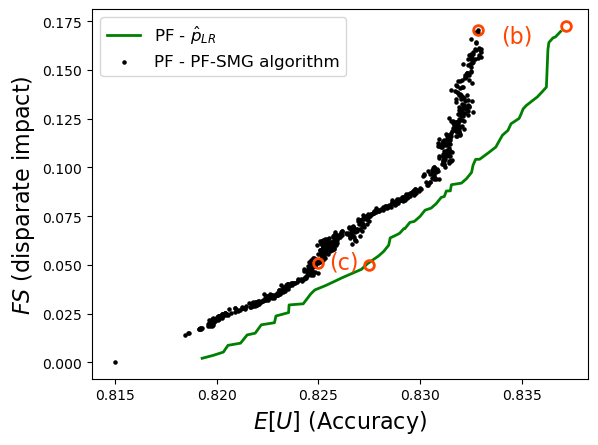

In [10]:
filled_marker_style = dict(marker='o', linestyle=':', markersize=7,
                           color='black',
                           markerfacecolor='black',
                           markerfacecoloralt='black',
                           markeredgecolor='orangered',
                           markeredgewidth=2)

PF_lb_lb_lr_sub = PF_lb_lb_lr[PF_lb_lb_lr.FS>0.002]
plt.plot(PF_lb_lb_lr_sub.iloc[:-1,:].U_avg, PF_lb_lb_lr_sub.iloc[:-1,:].FS, color = 'green', label = r'PF - $\hat{p}_{LR}$', lw=2)
plt.scatter(total_accuracy, CV_Score, color = 'black', s=5, label = 'PF - PF-SMG algorithm')
plt.plot(0.832828, 0.170656, fillstyle = 'none', **filled_marker_style)            #PFSMG
plt.plot(0.837154, 0.172552, fillstyle = 'none', **filled_marker_style)   
plt.plot(0.824996, 0.050915, fillstyle = 'none', **filled_marker_style)            #PFSMG
plt.plot(0.827482, 0.049972, fillstyle = 'none', **filled_marker_style)
plt.text(0.834, 0.164, '(b)', fontsize=16, color = 'orangered')
plt.text(0.8255, 0.048, '(c)', fontsize=16, color = 'orangered')
plt.legend(fontsize = 12)
plt.ylabel(r'$FS$ (disparate impact)', fontsize = 16)
plt.xlabel(r'$E[U]$ (Accuracy)', fontsize = 16)
plt.show()

5. Evaluate threshold rules in specifc points.

A) We first evaluate decision rules with a high accuracy and high FS (FS is around 0.17)

In [11]:
# Decision rule on the LR Pareto frontier with FS around 0.17
PF_lb_lb_lr[(PF_lb_lb_lr.FS>0.169)&(PF_lb_lb_lr.FS<0.171)]

,t0,t1,U_avg,FS,rule
10000,0.49,0.51,0.836905,0.169674,lb_lb


In [12]:
idx = PF_lb_lb_lr[(PF_lb_lb_lr.FS>0.169)&(PF_lb_lb_lr.FS<0.171)].index
# The corresponding thresholds
t_0 = PF_lb_lb_lr.loc[idx].t0.values[0]
t_1 = PF_lb_lb_lr.loc[idx].t1.values[0]

In [13]:
# PF-SMG decision rule on the Pareto frontier with FS around 0.17
PFSMG_df[(PFSMG_df[1]>0.169)&(PFSMG_df[1]<0.171)]

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
0,0.832753,0.169297,1.109194,-0.151978,3.345478,1.513540,1.071417,-0.232195,-0.878227,-0.320211,...,0.247692,-0.166684,0.025654,0.410864,-0.295486,0.238191,1.822458,-1.188366,-1.182244,-0.279177
1,0.832828,0.170656,1.221436,0.126954,3.008239,1.323175,1.407360,-0.181701,-0.863731,-0.441525,...,0.173396,0.595982,0.159053,0.012462,-0.687153,-0.451439,1.150768,-1.204129,-1.252571,-0.920327
2,0.832853,0.169158,1.240960,0.133500,3.002579,1.320194,1.401911,-0.176808,-0.875082,-0.420203,...,0.158136,0.579737,0.143161,0.011101,-0.679656,-0.439069,1.160515,-1.216704,-1.233230,-0.918616


In [14]:
# Weights from the decision rule with highest FS (index 1)
w = PFSMG_df.loc[1].values[2:]        # Weights with DI=0.17

data_test = Alldata[idx_test, :]
x_test = data_test[:,2:]
y_test = data_test[:,0]
z = x_test @ w
y_hat = np.where(z>=0,1,-1) # Decision for test data for this specific PF-SMG decision rule

df = pd.DataFrame(data_test[:,:2], columns=['y','a'])
df['idx'] = idx_test
df['y_transformed'] = df['y'].replace(-1,0)
df['y_hat'] = (y_hat+1)/2
df['p'] = p_lr[idx_test]

In [15]:
# Devide probability space into binns 
n_bins = 25 
x = np.linspace(0, 1, n_bins + 1)
bin_centers = (x[:-1] + x[1:]) / 2

df_0 = df[df.a == 0]
df_1 = df[df.a == 1]
# Determine per binn the fraction of individuals that is aasigned decision D=1 for each group
E_y_0 = []
E_y_1 = []
for i in np.arange(n_bins):
    df_sub_0 = df_0[(df_0.p > x[i]) & (df_0.p<= x[i+1])]
    n_rows_0 = len(df_sub_0)
    y_tot_0 = sum(df_sub_0.y_hat)
    df_sub_1 = df_1[(df_1.p > x[i]) & (df_1.p<= x[i+1])]
    n_rows_1 = len(df_sub_1)
    y_tot_1 = sum(df_sub_1.y_hat)
    if (n_rows_0 == 0):
        E_y_0.append(0)
    else:
        E_y_0.append(y_tot_0/n_rows_0)       
    if (n_rows_1 == 0):
        E_y_1.append(0)
    else:
        E_y_1.append(y_tot_1/n_rows_1)

df_thresholds = pd.DataFrame({'bin_center':bin_centers, 'd_0': E_y_0, 'd_1': E_y_1})

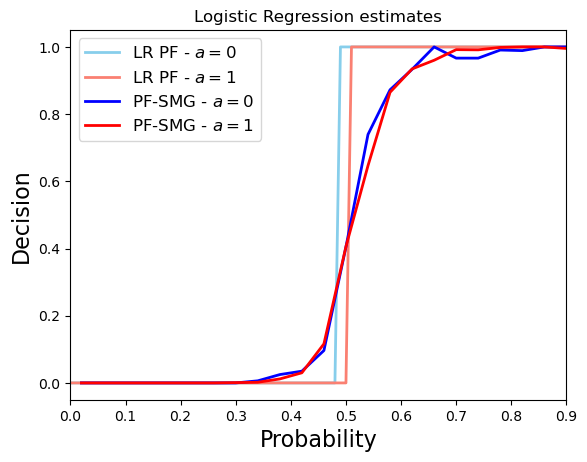

In [16]:
# Create step function for visualizing LR decision rule
x2 = np.linspace(0, 1, 100 + 1)
d_lr_0 = np.concatenate((np.zeros(len(np.where(x2<t_0)[0])) ,np.ones(len(np.where(x2>=t_0)[0])) ))
d_lr_1 = np.concatenate((np.zeros(len(np.where(x2<t_1)[0])) ,np.ones(len(np.where(x2>=t_1)[0])) ))

# Visualize decision rules 
plt.plot(x2,d_lr_0, label = r'LR PF - $a=0$', color = 'skyblue', ls = '-', lw= 2)
plt.plot(x2,d_lr_1, label = r'LR PF - $a=1$', color = 'salmon', ls = '-', lw =2 )
plt.plot(bin_centers, E_y_0, label=r'PF-SMG - $a=0$', color = 'blue', lw= 2)
plt.plot(bin_centers, E_y_1, label=r'PF-SMG - $a=1$', color = 'red', lw = 2)
plt.xlabel("Probability", fontsize=16)
plt.ylabel("Decision", fontsize =16)
plt.legend(fontsize = 12, loc = 'upper left')
plt.title('Logistic Regression estimates')
plt.xlim(0,0.9)
plt.show()

B) Evaluate threshold rules with FS around 0.05

In [17]:
# Decision rule on the LR Pareto frontier with FS around 0.05
PF_lb_lb_lr[(PF_lb_lb_lr.FS>0.049)&(PF_lb_lb_lr.FS<0.051)]

,t0,t1,U_avg,FS,rule
6386,0.31,0.62,0.827408,0.050598,lb_lb


In [18]:
idx = PF_lb_lb_lr[(PF_lb_lb_lr.FS>0.049)&(PF_lb_lb_lr.FS<0.051)].index
# The corresponding thresholds
t_0 = PF_lb_lb_lr.loc[idx].t0.values[0]
t_1 = PF_lb_lb_lr.loc[idx].t1.values[0]

In [19]:
# PF-SMG decision rule on the Pareto frontier with FS around 0.17
PFSMG_df[(PFSMG_df[1]>0.049)&(PFSMG_df[1]<0.051)]

,0,1,2,3,4,5,6,7,8,9,...,44,45,46,47,48,49,50,51,52,53
541,0.824474,0.049248,1.215033,0.140894,3.041075,1.383860,1.221849,-0.281060,-0.789776,-0.379071,...,0.096867,0.086217,-0.044641,0.096664,-0.471644,0.072598,1.493838,-1.150464,-1.151703,-0.623934
544,0.824598,0.049586,1.219091,0.121439,3.093958,1.369984,1.150367,-0.320727,-0.760289,-0.381119,...,-0.036694,0.021657,-0.060286,0.136696,-0.446448,0.156829,1.534658,-1.121954,-1.157065,-0.559521
532,0.824598,0.050979,1.273320,0.160455,2.966497,1.361379,1.404175,-0.209180,-0.821885,-0.399210,...,0.145662,0.409880,0.096939,0.008645,-0.612634,-0.272957,1.206026,-1.162523,-1.226594,-0.858135
526,0.824698,0.049436,1.187617,-0.057952,3.278601,1.430472,1.005375,-0.275417,-0.813244,-0.387797,...,0.182403,-0.139254,-0.040429,0.271535,-0.305049,0.306365,1.842883,-1.192854,-1.172160,-0.323209
524,0.824748,0.050853,1.231643,0.138608,3.050445,1.400383,1.217466,-0.285122,-0.783583,-0.379393,...,0.109152,0.145339,-0.024728,0.100001,-0.477663,0.023972,1.464136,-1.156150,-1.166854,-0.635818
535,0.824797,0.049540,1.226882,0.135191,3.049542,1.398993,1.219330,-0.284778,-0.777858,-0.395800,...,0.112175,0.145517,-0.029744,0.101405,-0.479160,0.022635,1.465438,-1.161175,-1.166687,-0.640727
528,0.824822,0.049206,1.213403,0.119640,3.107296,1.377109,1.138635,-0.313187,-0.779570,-0.392920,...,-0.029977,-0.040235,-0.066994,0.155415,-0.430373,0.179380,1.573294,-1.138185,-1.145508,-0.548977
525,0.824847,0.050611,1.221109,0.114901,3.110373,1.374770,1.139558,-0.326909,-0.787525,-0.366486,...,-0.021905,-0.054687,-0.049096,0.151135,-0.435083,0.180693,1.582672,-1.136136,-1.144548,-0.544954
538,0.824847,0.049352,1.224224,0.134092,3.090218,1.363658,1.152544,-0.318434,-0.786257,-0.377759,...,-0.035282,0.011981,-0.045419,0.136542,-0.449567,0.161992,1.522096,-1.114336,-1.164989,-0.562283
539,0.824847,0.049374,1.218297,0.147216,3.043098,1.392824,1.219865,-0.286623,-0.783026,-0.365920,...,0.103941,0.095844,-0.034232,0.099861,-0.475824,0.062043,1.485203,-1.157085,-1.147779,-0.625417


In [20]:
# Weights from the decision rule with index = 544
w = PFSMG_df.loc[544].values[2:]                                            #weights with DI=0.05

data_test = Alldata[idx_test, :]
x_test = data_test[:,2:]
y_test = data_test[:,0]
z = x_test @ w
y_hat = np.where(z>=0,1,-1) # Decision for test data for this specific PF-SMG decision rule

df = pd.DataFrame(data_test[:,:2], columns=['y','a'])
df['idx'] = idx_test
df['y_transformed'] = df['y'].replace(-1,0)
df['y_hat'] = (y_hat+1)/2
df['p'] = p_lr[idx_test]

In [21]:
# Devide probability space into binns 
n_bins = 25 
x = np.linspace(0, 1, n_bins + 1)
bin_centers = (x[:-1] + x[1:]) / 2

df_0 = df[df.a == 0]
df_1 = df[df.a == 1]
# Determine per binn the fraction of individuals that is aasigned decision D=1 for each group
E_y_0 = []
E_y_1 = []
for i in np.arange(n_bins):
    df_sub_0 = df_0[(df_0.p > x[i]) & (df_0.p<= x[i+1])]
    n_rows_0 = len(df_sub_0)
    y_tot_0 = sum(df_sub_0.y_hat)
    df_sub_1 = df_1[(df_1.p > x[i]) & (df_1.p<= x[i+1])]
    n_rows_1 = len(df_sub_1)
    y_tot_1 = sum(df_sub_1.y_hat)
    if (n_rows_0 == 0):
        E_y_0.append(0)
    else:
        E_y_0.append(y_tot_0/n_rows_0)       
    if (n_rows_1 == 0):
        E_y_1.append(0)
    else:
        E_y_1.append(y_tot_1/n_rows_1)

df_thresholds = pd.DataFrame({'bin_center':bin_centers, 'd_0': E_y_0, 'd_1': E_y_1})

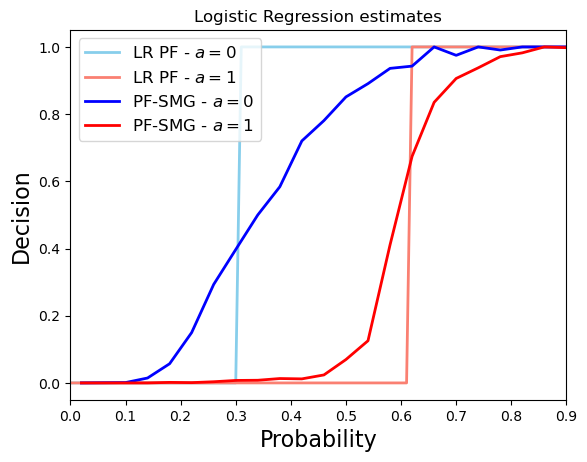

In [22]:
# Create step function for visualizing LR decision rule
x2 = np.linspace(0, 1, 100 + 1)
d_lr_0 = np.concatenate((np.zeros(len(np.where(x2<t_0)[0])) ,np.ones(len(np.where(x2>=t_0)[0])) ))
d_lr_1 = np.concatenate((np.zeros(len(np.where(x2<t_1)[0])) ,np.ones(len(np.where(x2>=t_1)[0])) ))

# Visualize decision rules 
plt.plot(x2,d_lr_0, label = r'LR PF - $a=0$', color = 'skyblue', ls = '-', lw= 2)
plt.plot(x2,d_lr_1, label = r'LR PF - $a=1$', color = 'salmon', ls = '-', lw =2 )
plt.plot(bin_centers, E_y_0, label=r'PF-SMG - $a=0$', color = 'blue', lw= 2)
plt.plot(bin_centers, E_y_1, label=r'PF-SMG - $a=1$', color = 'red', lw = 2)
plt.xlabel("Probability", fontsize=16)
plt.ylabel("Decision", fontsize =16)
plt.legend(fontsize = 12, loc = 'upper left')
plt.title('Logistic Regression estimates')
plt.xlim(0,0.9)
plt.show()

In [25]:
PFSMG_df_sub = PFSMG_df[(PFSMG_df[1]>0.049)&(PFSMG_df[1]<0.051)]


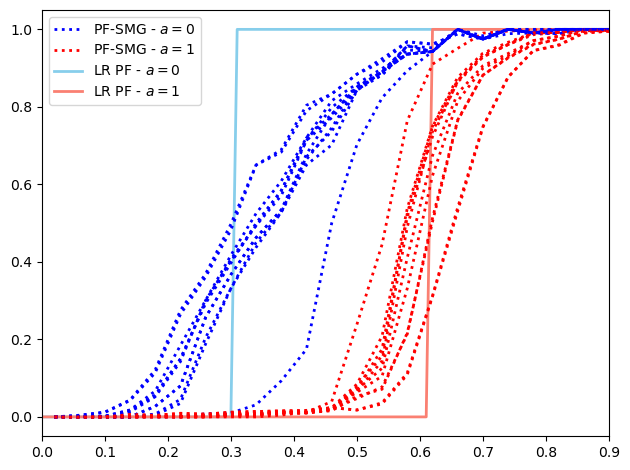

In [26]:
for j, row in enumerate(PFSMG_df_sub.iterrows()):
    index, data = row 
    w = data[2:].values
    z = x_test @ w
    y_hat = np.where(z>=0,1,-1) # Decision for test data for this specific PF-SMG decision rule
    
    df = pd.DataFrame(data_test[:,:2], columns=['y','a'])
    df['idx'] = idx_test
    df['y_transformed'] = df['y'].replace(-1,0)
    df['y_hat'] = (y_hat+1)/2
    df['p'] = p_lr[idx_test]

    n_bins = 25 
    x = np.linspace(0, 1, n_bins + 1)
    bin_centers = (x[:-1] + x[1:]) / 2
    
    df_0 = df[df.a == 0]
    df_1 = df[df.a == 1]
    # Determine per binn the fraction of individuals that is aasigned decision D=1 for each group
    E_y_0 = []
    E_y_1 = []
    for i in np.arange(n_bins):
        df_sub_0 = df_0[(df_0.p > x[i]) & (df_0.p<= x[i+1])]
        n_rows_0 = len(df_sub_0)
        y_tot_0 = sum(df_sub_0.y_hat)
        df_sub_1 = df_1[(df_1.p > x[i]) & (df_1.p<= x[i+1])]
        n_rows_1 = len(df_sub_1)
        y_tot_1 = sum(df_sub_1.y_hat)
        if (n_rows_0 == 0):
            E_y_0.append(0)
        else:
            E_y_0.append(y_tot_0/n_rows_0)       
        if (n_rows_1 == 0):
            E_y_1.append(0)
        else:
            E_y_1.append(y_tot_1/n_rows_1)
    
    df_thresholds = pd.DataFrame({'bin_center':bin_centers, 'd_0': E_y_0, 'd_1': E_y_1})

    
    plt.plot(bin_centers, E_y_0, label=r'PF-SMG - $a=0$', color = 'blue', lw= 2, ls = ':')
    plt.plot(bin_centers, E_y_1, label=r'PF-SMG - $a=1$', color = 'red', lw = 2, ls = ':')
    if(j==0):
        plt.plot(x2,d_lr_0, label = r'LR PF - $a=0$', color = 'skyblue', ls = '-', lw= 2)
        plt.plot(x2,d_lr_1, label = r'LR PF - $a=1$', color = 'salmon', ls = '-', lw =2 )
        plt.legend()


plt.xlim(0,0.9)
plt.tight_layout()
plt.show()
    

In [27]:
PFSMG_df_sub = PFSMG_df[(PFSMG_df[1]>0.049)&(PFSMG_df[1]<0.051)]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(12, 16))
axes_flat = axes.flatten()

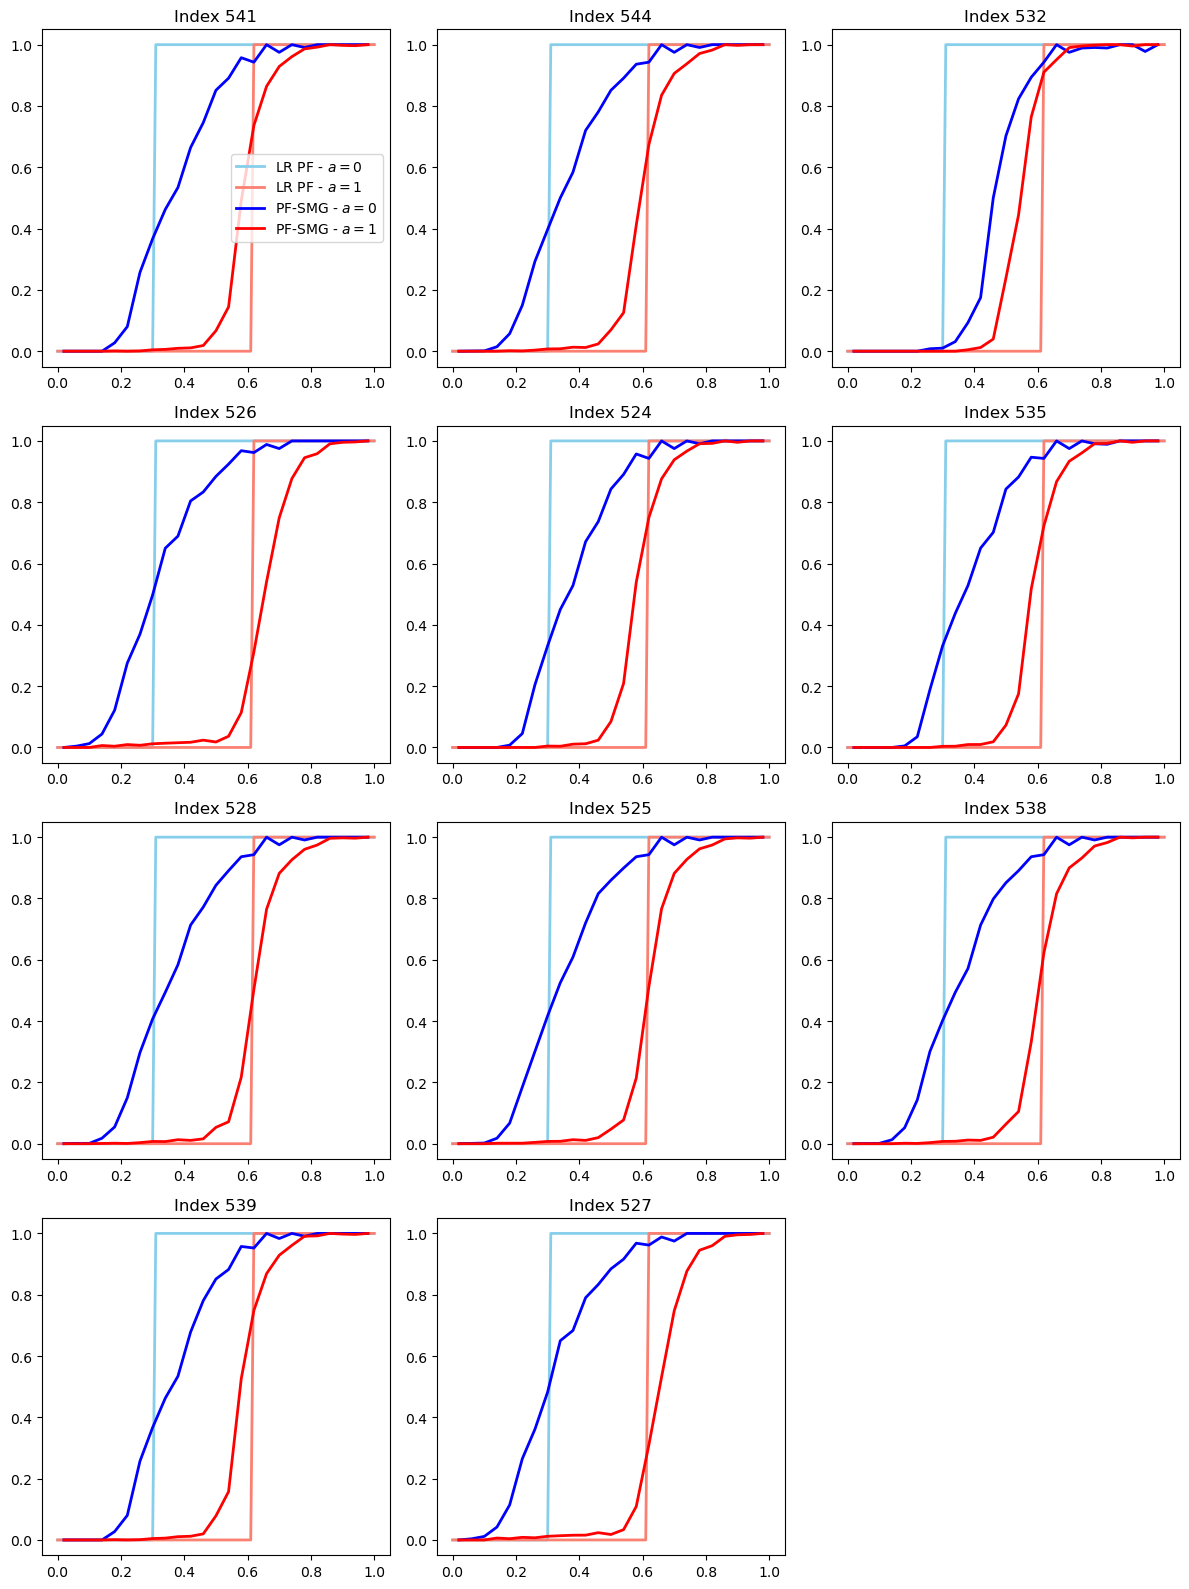

In [28]:
for j, row in enumerate(PFSMG_df_sub.iterrows()):
    index, data = row 
    w = data[2:].values
    z = x_test @ w
    y_hat = np.where(z>=0,1,-1) # Decision for test data for this specific PF-SMG decision rule
    
    df = pd.DataFrame(data_test[:,:2], columns=['y','a'])
    df['idx'] = idx_test
    df['y_transformed'] = df['y'].replace(-1,0)
    df['y_hat'] = (y_hat+1)/2
    df['p'] = p_lr[idx_test]

    n_bins = 25 
    x = np.linspace(0, 1, n_bins + 1)
    bin_centers = (x[:-1] + x[1:]) / 2
    
    df_0 = df[df.a == 0]
    df_1 = df[df.a == 1]
    # Determine per binn the fraction of individuals that is aasigned decision D=1 for each group
    E_y_0 = []
    E_y_1 = []
    for i in np.arange(n_bins):
        df_sub_0 = df_0[(df_0.p > x[i]) & (df_0.p<= x[i+1])]
        n_rows_0 = len(df_sub_0)
        y_tot_0 = sum(df_sub_0.y_hat)
        df_sub_1 = df_1[(df_1.p > x[i]) & (df_1.p<= x[i+1])]
        n_rows_1 = len(df_sub_1)
        y_tot_1 = sum(df_sub_1.y_hat)
        if (n_rows_0 == 0):
            E_y_0.append(0)
        else:
            E_y_0.append(y_tot_0/n_rows_0)       
        if (n_rows_1 == 0):
            E_y_1.append(0)
        else:
            E_y_1.append(y_tot_1/n_rows_1)
    
    df_thresholds = pd.DataFrame({'bin_center':bin_centers, 'd_0': E_y_0, 'd_1': E_y_1})

    ax = axes_flat[j]
    ax.plot(x2,d_lr_0, label = r'LR PF - $a=0$', color = 'skyblue', ls = '-', lw= 2)
    ax.plot(x2,d_lr_1, label = r'LR PF - $a=1$', color = 'salmon', ls = '-', lw =2 )
    ax.plot(bin_centers, E_y_0, label=r'PF-SMG - $a=0$', color = 'blue', lw= 2)
    ax.plot(bin_centers, E_y_1, label=r'PF-SMG - $a=1$', color = 'red', lw = 2)
    ax.set_title(f"Index {index}")
    if(j==0):
        ax.legend()

axes_flat[11].axis('off')

plt.tight_layout()
plt.show()
    

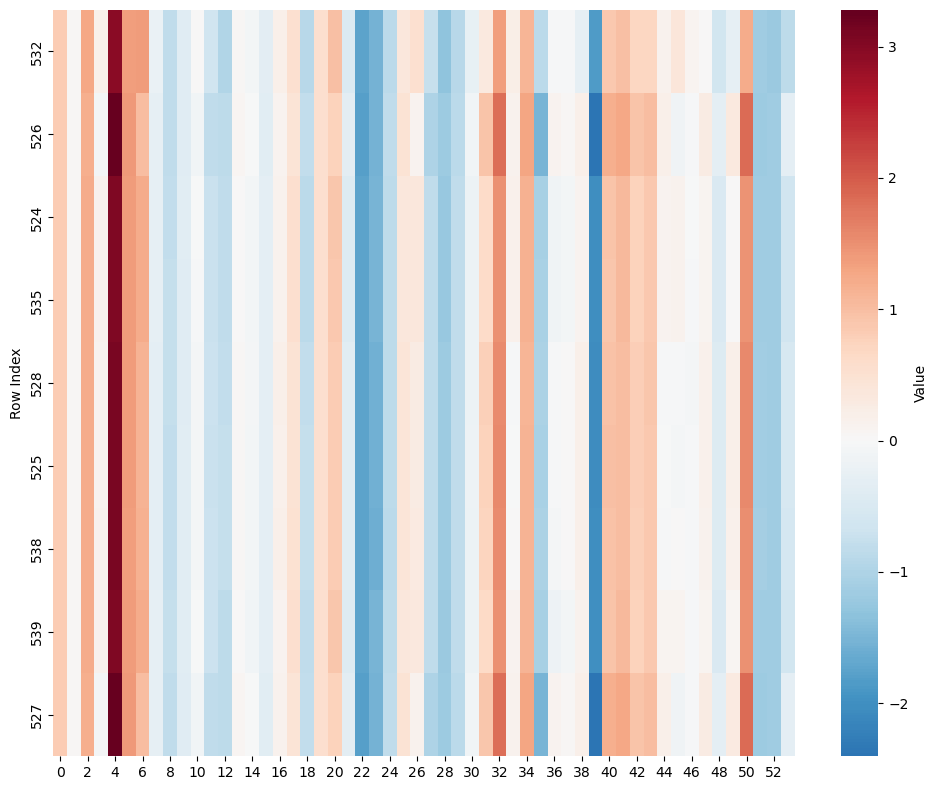

In [29]:
# Heatmap of feature weights of the different PF-SMG decision rules that have a FS close to 0.05 
plt.figure(figsize=(10, 8))
sns.heatmap(PFSMG_df_sub[2:], 
            cmap='RdBu_r',       # Diverging colormap
            center=0,             # Zero is in the middle (white)
            vmin=None,            # Optional: force min value for color scale consistency
            vmax=None,            # Optional: force max value
            annot=False,           # Show values in cells (set to False if too crowded)
            fmt='.2f',            # Format for numbers
            cbar_kws={'label': 'Value'}
           )
plt.ylabel('Row Index')
plt.tight_layout()
plt.show()